In [20]:
import numpy as np

from lips_H_old import run_lips_h

# old 
T = 300000
noise_std = 0.1

eps_list = [2.0, 1.7]

eps_seeds = {
    2.0: list(range(1, 11)),
    1.7: list(range(11, 21)),
}

gap = 6000
ts = np.arange(gap, T + 1, gap, dtype=int)

# ys_old_by_eps[eps] shape: (len(seeds), len(ts))
ys_old_by_eps = {}
for eps in eps_list:
    runs = []
    for seed in eps_seeds[eps]:
        res = run_lips_h(T=T, noise_std=noise_std, seed=seed, eps=eps)
        regret = res.regretlist
        runs.append([regret[t] for t in ts])
    ys_old_by_eps[eps] = np.asarray(runs, dtype=float)

mean_old_by_eps = {eps: ys_old_by_eps[eps].mean(axis=0) for eps in eps_list}

print("old shapes:", {eps: ys_old_by_eps[eps].shape for eps in eps_list})

old shapes: {2.0: (10, 50), 1.7: (10, 50)}


In [21]:
import numpy as np

from lips_H_new import run_lips_h

# new 
T = 300000
noise_std = 0.1

eps_list = [2.0, 1.7]

eps_seeds = {
    2.0: list(range(1, 11)),
    1.7: list(range(11, 21)),
}

gap = 6000
ts = np.arange(gap, T + 1, gap, dtype=int)

# ys_new_by_eps[eps] shape: (len(seeds), len(ts))
ys_new_by_eps = {}
for eps in eps_list:
    runs = []
    for seed in eps_seeds[eps]:
        res = run_lips_h(T=T, noise_std=noise_std, seed=seed, eps=eps)
        regret = res.regretlist
        runs.append([regret[t] for t in ts])
    ys_new_by_eps[eps] = np.asarray(runs, dtype=float)

mean_new_by_eps = {eps: ys_new_by_eps[eps].mean(axis=0) for eps in eps_list}

print("new shapes:", {eps: ys_new_by_eps[eps].shape for eps in eps_list})

new shapes: {2.0: (10, 50), 1.7: (10, 50)}


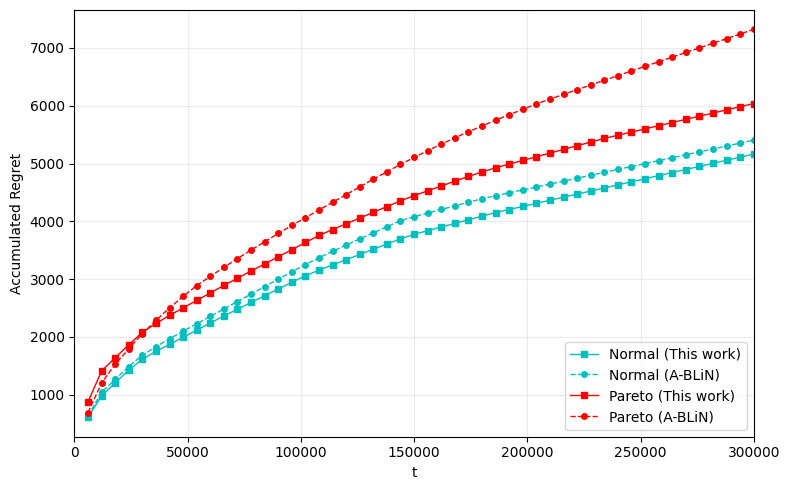

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

y_old_20 = mean_old_by_eps[2.0]
y_new_20 = mean_new_by_eps[2.0]
y_old_17 = mean_old_by_eps[1.7]
y_new_17 = mean_new_by_eps[1.7]
plt.plot(ts, y_new_20, "c-s", markerfacecolor="c", linewidth=1, markersize=4, label="Normal (This work)")
plt.plot(ts, y_old_20, "c--o", markerfacecolor="c", linewidth=1, markersize=4, label="Normal (A-BLiN)")
plt.plot(ts, y_new_17, "r-s", markerfacecolor="r", linewidth=1, markersize=4, label="Pareto (This work)")
plt.plot(ts, y_old_17, "r--o", markerfacecolor="r", linewidth=1, markersize=4, label="Pareto (A-BLiN)")


plt.xlim([0, T])
plt.xlabel("t")
plt.ylabel("Accumulated Regret")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("fig1.png")
plt.show()

<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
C:\Users\32383\AppData\Local\Temp\ipykernel_34040\2040267111.py:27: SyntaxWarning: invalid escape sequence '\m'
  ax.set_zlabel("$\mu(x, y)$")
C:\Users\32383\AppData\Local\Temp\ipykernel_34040\2040267111.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right")


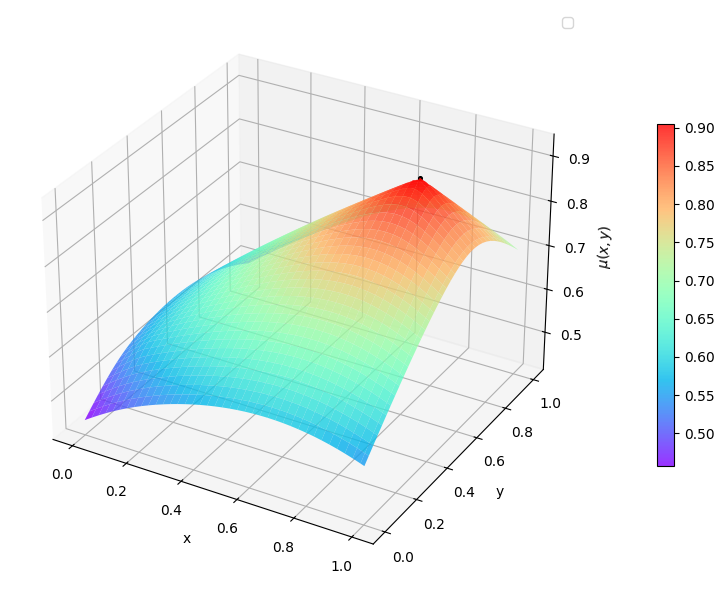

In [26]:
import numpy as np
import matplotlib.pyplot as plt

from lips_H_new import mu

xs = np.linspace(0.0, 1.0, 151)
ys = np.linspace(0.0, 1.0, 151)
X, Y = np.meshgrid(xs, ys, indexing="xy")

Z = np.vectorize(mu)(X, Y)

x_max = 0.8
y_max = 0.7
z_max = float(mu(x_max, y_max))

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(X, Y, Z, cmap="rainbow", linewidth=0, antialiased=True,alpha=0.8)
fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1)

ax.scatter([x_max], [y_max], [z_max], c="k", s=7, depthshade=False)
ax.legend(loc="upper right")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("$\mu(x, y)$")
plt.tight_layout()
plt.show()